# Processamento de Dados dos Influenciadores

Este notebook realiza a extração, tratamento e estruturação dos dados brutos em camadas analíticas.

**Decisão Metodológica Central**: Os posts com `comments_count == 0` NÃO são filtrados da base principal, pois representam uma classe válida de engajamento na plataforma (90%+ dos dados). A filtragem de zeros ocorrerá apenas em uma camada específica (`core_2017_2019`) voltada para testes de robustez.

## Camadas de Dados Geradas
1. `posts_base_completa.parquet`: Tratamento mínimo, sem filtros.
2. `posts_base_2017_2019.parquet`: **DATASET ANALÍTICO PRINCIPAL**. Filtro de data (2017-2019) e followers > 0.
3. `posts_core_2017_2019.parquet`: Subconjunto do principal, com `comments_count > 0` para testes de robustez.
4. Camadas de CV (`cv_core_2017_2019.parquet`, `cv_core_anual.parquet`): Métricas de estabilidade.


In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pl.Config.set_tbl_rows(10)
pl.Config.set_fmt_str_lengths(50)

polars.config.Config

In [2]:
# Caminhos de entrada
PARQUET_POSTS = "posts.parquet"
CSV_INFLUENCERS = "dataframe_influencers.csv"

# Caminhos de saida
DIRETORIO = Path("bases-processadas/")

PARQUET_BASE_COMPLETA = f"{DIRETORIO}/posts_base_completa.parquet"
PARQUET_BASE_2017_2019 = f"{DIRETORIO}/posts_base_2017_2019.parquet"
PARQUET_CORE_2017_2019 = f"{DIRETORIO}/posts_core_2017_2019.parquet"


PARQUET_CV_BASE = f"{DIRETORIO}/cv_base_2017_2019.parquet"
PARQUET_CV_ANUAL_BASE = f"{DIRETORIO}/cv_base_anual.parquet"

PARQUET_CV_CORE = f"{DIRETORIO}/cv_core_2017_2019.parquet"
PARQUET_CV_ANUAL_CORE = f"{DIRETORIO}/cv_core_anual.parquet"

## 1. Carga da Base Bruta

In [3]:
df = pl.read_parquet(PARQUET_POSTS)
df.shape

(9726198, 20)

In [4]:
df.head()

post_id,username,inf_category,followers,followees,posts_total,is_verified,data,timestamp_unix,likes,comments_count,post_type,n_imagens,aspect_ratio,is_sponsored,n_hashtags,n_usertags,caption_len,has_location,accessibility
str,str,str,i64,i64,i64,bool,str,i64,i64,i64,str,i64,f64,bool,i64,i64,i64,bool,str
"""BmlIb5Xld5f""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-17""",1534509290,51,2,"""image""",1,0.8,false,18,1,257,false,""""""
"""BmlI2LPlblP""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-17""",1534509505,89,0,"""image""",1,0.8,false,17,1,279,false,""""""
"""BmoH1VclTxO""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-18""",1534609638,94,0,"""image""",1,0.8,false,16,1,228,false,""""""
"""Bmd0fuolkUZ""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-14""",1534263955,66,4,"""carousel""",2,0.8,true,17,1,282,false,"""Image may contain: 2 people, indoor | Image may co…"
"""Bmd445DFh7t""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-14""",1534266258,64,0,"""carousel""",4,0.8,false,18,1,255,false,"""Image may contain: 1 person, closeup | Image may c…"


## 2. Qualidade e Integridade dos Dados

- Valores nulos

In [5]:
print("Valores Nulos por Coluna:")
df.null_count()

Valores Nulos por Coluna:


post_id,username,inf_category,followers,followees,posts_total,is_verified,data,timestamp_unix,likes,comments_count,post_type,n_imagens,aspect_ratio,is_sponsored,n_hashtags,n_usertags,caption_len,has_location,accessibility
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


- Influenciadores únicos

In [6]:
posts_por_perfil = df.group_by("username").agg(pl.len().alias("n_posts")).sort("n_posts", descending=True)
posts_por_perfil.describe()

statistic,username,n_posts
str,str,f64
"""count""","""33840""",33840.0
"""null_count""","""0""",0.0
"""mean""",null,287.417199
"""std""",null,37.518166
"""min""","""00_rocketgirl""",1.0
"""25%""",null,297.0
"""50%""",null,300.0
"""75%""",null,300.0
"""max""","""zyndl_lala""",300.0


- Posts por influenciador

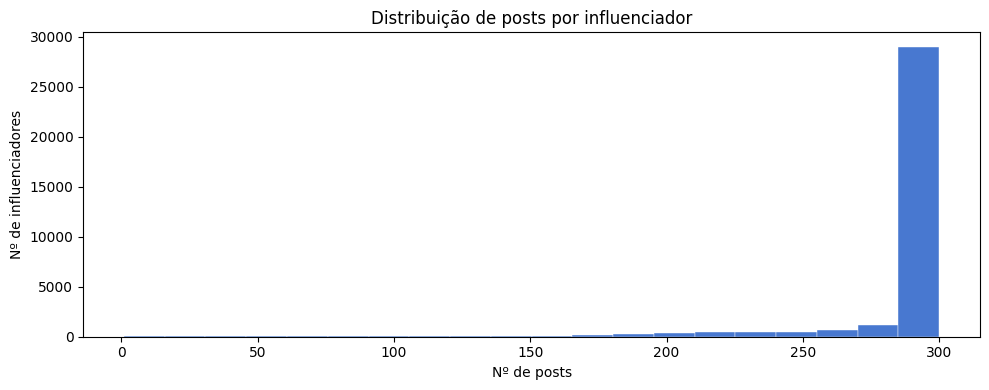

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    posts_por_perfil["n_posts"].to_numpy(),
    bins=20,
    color=sns.color_palette("muted")[0],
    edgecolor="white", linewidth=0.3,
)
ax.set_xlabel("Nº de posts")
ax.set_ylabel("Nº de influenciadores")
ax.set_title("Distribuição de posts por influenciador")
plt.tight_layout()
plt.show()

## 3. Cobertura do Lookup de Influenciadores


In [8]:
total = df.shape[0]

In [11]:
df_inf = pl.read_csv(CSV_INFLUENCERS)
usernames = df_inf.select("Username").unique()

In [12]:
sem_followers = df.filter(pl.col("followers").is_null()).shape[0]
followers_zero = df.filter(pl.col("followers") == 0).shape[0]
followers_ok = df.filter(pl.col("followers") > 0).shape[0]

print(f"Total de posts: {total}")
print(f"Com followers > 0: {followers_ok}  ({followers_ok/total*100:.1f}%)")
print(f"Com followers = 0: {followers_zero}  ({followers_zero/total*100:.1f}%)")
print(f"Com followers nulo: {sem_followers}  ({sem_followers/total*100:.1f}%)")

Total de posts: 9726198
Com followers > 0: 9566651  (98.4%)
Com followers = 0: 159547  (1.6%)
Com followers nulo: 0  (0.0%)


In [14]:
df = df.with_columns(pl.col("username").is_in(usernames["Username"]).alias("perfil_completo_lookup"))

C:\Users\cruzd\AppData\Local\Temp\ipykernel_1320\219604492.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df = df.with_columns(pl.col("username").is_in(usernames["Username"]).alias("perfil_completo_lookup"))


## 4. Cobertura Temporal

In [15]:
df = df.with_columns(
    pl.col("data").str.to_date("%Y-%m-%d", strict=False).alias("data_dt")
)
df.filter(pl.col("data_dt").is_not_null())['data_dt'].min(), df.filter(pl.col("data_dt").is_not_null())['data_dt'].max()

(datetime.date(2012, 2, 10), datetime.date(2019, 5, 15))

In [16]:
df = df.with_columns(pl.col("data_dt").dt.year().alias("ano"))
dist_anual = df.group_by("ano").agg(pl.len().alias("n_posts")).sort("ano")
dist_anual = dist_anual.with_columns((pl.col("n_posts") / pl.col("n_posts").sum() * 100).alias("pct"))
dist_anual

ano,n_posts,pct
i32,u32,f64
2012,1649,0.016954
2013,10421,0.107144
2014,35241,0.362331
2015,117036,1.203307
2016,514954,5.294505
2017,1805339,18.561611
2018,5249771,53.975572
2019,1991787,20.478578


- Concentração de postagens por categorias por ano

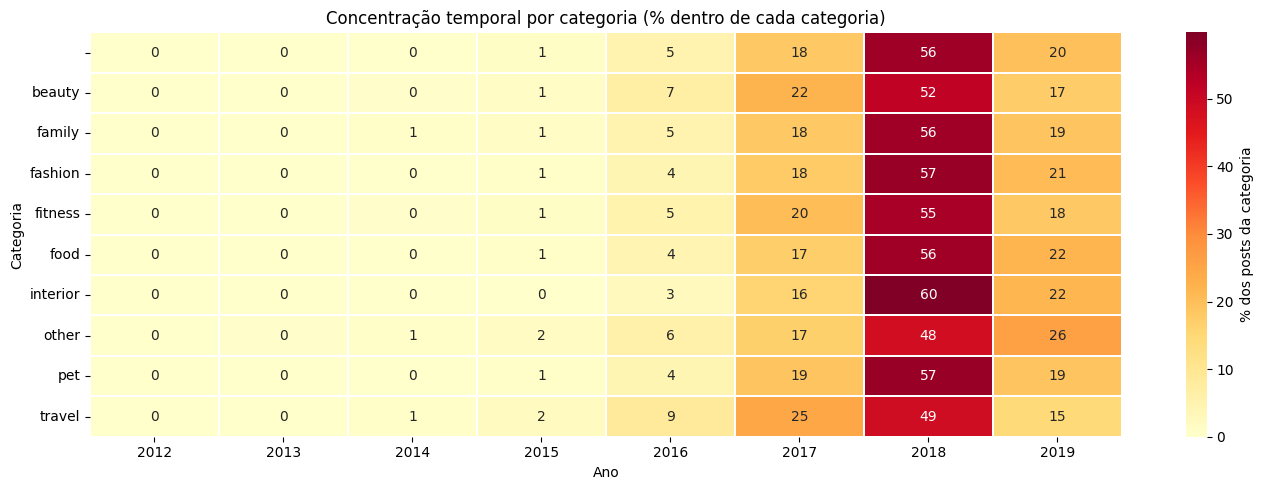

In [17]:
cat_ano = (
    df.filter(pl.col("data_dt").is_not_null())
    .with_columns(pl.col("data_dt").dt.year().alias("ano"))
    .group_by(["inf_category", "ano"])
    .agg(pl.len().alias("n"))
    .sort(["inf_category", "ano"])
    .to_pandas()
)

pivot = cat_ano.pivot_table(index="inf_category", columns="ano", values="n", fill_value=0)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_pct, ax=ax,
    cmap="YlOrRd", annot=True, fmt=".0f",
    linewidths=0.3,
    cbar_kws={"label": "% dos posts da categoria"},
)
ax.set_title("Concentração temporal por categoria (% dentro de cada categoria)")
ax.set_xlabel("Ano")
ax.set_ylabel("Categoria")
plt.tight_layout()
plt.show()

## 5. Diagnóstico de Zeros e Decisão Metodológica


In [18]:
likes_zero = df.filter(pl.col("likes") == 0).shape[0]
comments_zero = df.filter(pl.col("comments_count") == 0).shape[0]
total = df.shape[0]

print(f"Posts com likes = 0 : {likes_zero} ({likes_zero/total*100:.2f}%)")
print(f"Posts com comments = 0 : {comments_zero} ({comments_zero/total*100:.2f}%)")

Posts com likes = 0 : 3044 (0.03%)
Posts com comments = 0 : 8830004 (90.79%)


- Distribuição de posts com 0 likes e 0 comments por categoria

shape: (9, 2)
┌──────────────┬──────┐
│ inf_category ┆ n    │
│ ---          ┆ ---  │
│ str          ┆ u32  │
╞══════════════╪══════╡
│ other        ┆ 2215 │
│ travel       ┆ 299  │
│ family       ┆ 195  │
│ food         ┆ 134  │
│ pet          ┆ 76   │
│ fashion      ┆ 72   │
│              ┆ 30   │
│ beauty       ┆ 14   │
│ fitness      ┆ 3    │
└──────────────┴──────┘


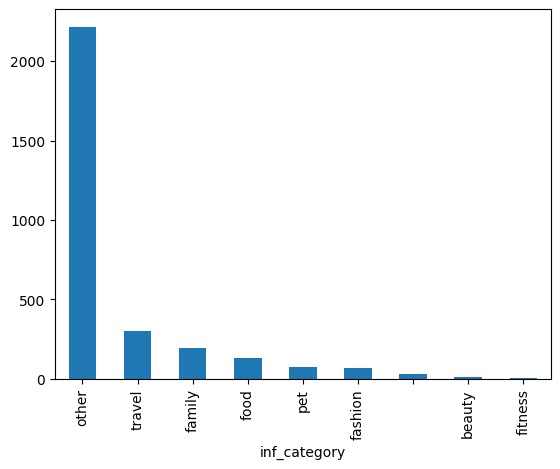

In [19]:
zeros = df.filter((pl.col("likes") == 0) & (pl.col("comments_count") == 0))
dist = (
    zeros.group_by("inf_category")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)
print(dist)

(dist.to_pandas()
 .plot.bar(x="inf_category",y="n",legend=False));

## 6. Definição das Camadas do Dataset

In [20]:
base_completa = df.drop("ano")
print(f"Base Completa: {base_completa.shape}")

Base Completa: (9726198, 22)


In [21]:
base_2017_2019 = base_completa.filter(
    pl.col("data_dt").is_not_null(),
    pl.col("data_dt").dt.year().is_between(2017, 2019),
    pl.col("followers") > 0
)
print(f"Base 2017-2019 (Principal): {base_2017_2019.shape}")

Base 2017-2019 (Principal): (8897233, 22)


O dataset `core_2017_2019` será criado mais adiante, após a inclusão das métricas.

## 7. Métricas Derivadas na Base Principal

In [22]:
base_2017_2019 = base_2017_2019.with_columns([
    ((pl.col("likes") + pl.col("comments_count")) / pl.col("followers") * 100).alias("er_classico"),
    ((pl.col("likes") + pl.col("comments_count") * 2) / pl.col("followers") * 100).alias("er_weighted")
])
base_2017_2019.select(["er_classico", "er_weighted"]).describe()

statistic,er_classico,er_weighted
str,f64,f64
"""count""",8.897233e6,8.897233e6
"""null_count""",0.0,0.0
"""mean""",4.327969,4.349675
"""std""",5.291196,5.33094
"""min""",0.0,0.0
"""25%""",1.569472,1.575025
"""50%""",3.020962,3.033254
"""75%""",5.491529,5.516313
"""max""",1408.70425,1408.70425


## 8. Segmentação e Buckets

Além do valor de er_classico e er_weighted, cada post recebe três classificações que contextualizam seu nível de engajamento dentro do estrato de mercado

- Buckets de followers com limite de n° de seguidores

In [23]:
base_2017_2019 = base_2017_2019.with_columns(
    pl.when(pl.col("followers") <= 10_000).then(pl.lit("nano"))
    .when(pl.col("followers") <= 100_000).then(pl.lit("micro"))
    .when(pl.col("followers") <= 500_000).then(pl.lit("mid-tier"))
    .when(pl.col("followers") <= 1_000_000).then(pl.lit("macro"))
    .otherwise(pl.lit("mega")).alias("bucket_followers")
)

- Buckets da industria a partir do valor de ER

In [24]:
base_2017_2019 = base_2017_2019.with_columns(
    pl.when(pl.col("er_classico") < 1).then(pl.lit("LOW"))
    .when(pl.col("er_classico") < 3.5).then(pl.lit("MEDIUM"))
    .when(pl.col("er_classico") < 6).then(pl.lit("HIGH"))
    .otherwise(pl.lit("VIRAL")).alias("er_bucket_industria")
)

- Buckets por percentil de er classico

In [25]:
q25 = base_2017_2019["er_classico"].quantile(0.25)
q50 = base_2017_2019["er_classico"].quantile(0.50)
q75 = base_2017_2019["er_classico"].quantile(0.75)

base_2017_2019 = base_2017_2019.with_columns(
    pl.when(pl.col("er_classico") <= q25).then(pl.lit("Q1"))
    .when(pl.col("er_classico") <= q50).then(pl.lit("Q2"))
    .when(pl.col("er_classico") <= q75).then(pl.lit("Q3"))
    .otherwise(pl.lit("Q4")).alias("er_bucket_percentil")
)

- Buckets adaptados para +/- desvio padrão de er classico

In [26]:
thresholds = (
    base_2017_2019.filter(pl.col("er_classico") > 0)
    .group_by("bucket_followers")
    .agg([
        pl.col("er_classico").mean().alias("er_media_bucket"),
        pl.col("er_classico").std().alias("er_std_bucket"),
    ])
    .with_columns([
        (pl.col("er_media_bucket") - pl.col("er_std_bucket")).alias("thresh_low"),
        (pl.col("er_media_bucket") + pl.col("er_std_bucket")).alias("thresh_high"),
    ])
)

base_2017_2019 = base_2017_2019.join(thresholds, on="bucket_followers", how="left")

base_2017_2019 = base_2017_2019.with_columns(
    pl.when(pl.col("er_classico") < pl.col("thresh_low")).then(pl.lit("LOW"))
    .when(pl.col("er_classico") < pl.col("thresh_high")).then(pl.lit("MEDIUM"))
    .when(pl.col("er_classico") < (pl.col("thresh_high") + pl.col("er_std_bucket"))).then(pl.lit("HIGH"))
    .otherwise(pl.lit("VIRAL")).alias("adapted_bucket")
)

In [27]:
base_2017_2019

post_id,username,inf_category,followers,followees,posts_total,is_verified,data,timestamp_unix,likes,comments_count,post_type,n_imagens,aspect_ratio,is_sponsored,n_hashtags,n_usertags,caption_len,has_location,accessibility,perfil_completo_lookup,data_dt,er_classico,er_weighted,bucket_followers,er_bucket_industria,er_bucket_percentil,er_media_bucket,er_std_bucket,thresh_low,thresh_high,adapted_bucket
str,str,str,i64,i64,i64,bool,str,i64,i64,i64,str,i64,f64,bool,i64,i64,i64,bool,str,bool,date,f64,f64,str,str,str,f64,f64,f64,f64,str
"""BmlIb5Xld5f""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-17""",1534509290,51,2,"""image""",1,0.8,false,18,1,257,false,"""""",true,2018-08-17,2.609552,2.708026,"""nano""","""MEDIUM""","""Q2""",5.3779,6.556056,-1.178156,11.933956,"""MEDIUM"""
"""BmlI2LPlblP""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-17""",1534509505,89,0,"""image""",1,0.8,false,17,1,279,false,"""""",true,2018-08-17,4.382078,4.382078,"""nano""","""HIGH""","""Q3""",5.3779,6.556056,-1.178156,11.933956,"""MEDIUM"""
"""BmoH1VclTxO""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-18""",1534609638,94,0,"""image""",1,0.8,false,16,1,228,false,"""""",true,2018-08-18,4.628262,4.628262,"""nano""","""HIGH""","""Q3""",5.3779,6.556056,-1.178156,11.933956,"""MEDIUM"""
"""Bmd0fuolkUZ""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-14""",1534263955,66,4,"""carousel""",2,0.8,true,17,1,282,false,"""Image may contain: 2 people, indoor | Image may co…",true,2018-08-14,3.446578,3.643525,"""nano""","""MEDIUM""","""Q3""",5.3779,6.556056,-1.178156,11.933956,"""MEDIUM"""
"""Bmd445DFh7t""","""00s_supermodels""","""fashion""",2031,53,2520,false,"""2018-08-14""",1534266258,64,0,"""carousel""",4,0.8,false,18,1,255,false,"""Image may contain: 1 person, closeup | Image may c…",true,2018-08-14,3.151157,3.151157,"""nano""","""MEDIUM""","""Q3""",5.3779,6.556056,-1.178156,11.933956,"""MEDIUM"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""BvbvpBBhFNa""","""________erikaitou___""","""fashion""",16566,514,418,false,"""2019-03-25""",1553521653,428,0,"""image""",1,1.0,false,1,0,22,false,"""""",true,2019-03-25,2.583605,2.583605,"""micro""","""MEDIUM""","""Q2""",3.861336,4.545421,-0.684085,8.406757,"""MEDIUM"""
"""BvjJ0t1hyij""","""________erikaitou___""","""fashion""",16566,514,418,false,"""2019-03-28""",1553770262,318,0,"""image""",1,1.0,false,6,1,155,false,"""""",true,2019-03-28,1.919594,1.919594,"""micro""","""MEDIUM""","""Q2""",3.861336,4.545421,-0.684085,8.406757,"""MEDIUM"""
"""Bvjdk98B_Df""","""________erikaitou___""","""fashion""",16566,514,418,false,"""2019-03-28""",1553780618,726,0,"""image""",1,1.0,false,2,0,101,false,"""""",true,2019-03-28,4.38247,4.38247,"""micro""","""HIGH""","""Q3""",3.861336,4.545421,-0.684085,8.406757,"""MEDIUM"""


## 9. Métricas de Estabilidade (CV) no Core

O CV é o Coeficiente de Variação do ER

- CV do dataset base

In [ ]:
cv_base = (
    base_2017_2019.group_by("username")
    .agg([
        pl.len().alias("n_posts_validos"),
        pl.col("er_classico").mean().alias("er_media"),
        pl.col("er_classico").std().alias("er_std"),
        pl.col("er_classico").median().alias("er_mediana"),
    ])
    .filter(pl.col("n_posts_validos") >= 5)
    .with_columns(
        pl.when(pl.col("er_media") == 0).then(None)
        .otherwise(pl.col("er_std") / pl.col("er_media")).alias("cv")
    )
)
cv_base.head()

username,n_posts_validos,er_media,er_std,er_mediana,cv
str,u32,f64,f64,f64,f64
"""alenafoodphoto""",300,2.49755,1.300702,2.340015,0.520791
"""dreamworkstv""",300,1.329916,0.674515,1.236159,0.507186
"""iamdajana""",299,2.407712,0.953432,2.272727,0.395991
"""theegoogoo""",299,0.659628,0.825345,0.371487,1.251229
"""heyjodeblog""",251,3.998959,1.628206,3.92253,0.407158


In [ ]:
cv_anual_base = (
    base_2017_2019.with_columns(pl.col("data_dt").dt.year().alias("ano"))
    .group_by(["username", "ano"])
    .agg([
        pl.len().alias("n_posts_validos"),
        pl.col("er_classico").mean().alias("er_media"),
        pl.col("er_classico").std().alias("er_std"),
    ])
    .filter(pl.col("n_posts_validos") >= 5)
    .with_columns(
        pl.when(pl.col("er_media") == 0).then(None)
        .otherwise(pl.col("er_std") / pl.col("er_media")).alias("cv")
    )
)

In [ ]:
cv_anual_base.sort(by="cv")

username,ano,n_posts_validos,er_media,er_std,cv
str,i32,u32,f64,f64,f64
"""katreena""",2019,5,2.35497,0.020263,0.008604
"""themagnoliamom""",2019,40,1.207172,0.022183,0.018376
"""nathanyelbns""",2019,109,3.117091,0.067698,0.021718
"""largerfamilylife""",2019,8,2.170214,0.055683,0.025658
"""marta__lu""",2018,143,1.219965,0.032434,0.026586
…,…,…,…,…,…
"""namastejenay""",2018,242,7.612701,58.796172,7.723431
"""gregnoire""",2018,201,12.347413,99.026667,8.020034
"""_cm0""",2018,208,2.526901,20.960618,8.29499


- CV core : periodo 2017-2019 também mas com comments_count > 0

In [ ]:
core_2017_2019 = base_2017_2019.filter(pl.col("comments_count") > 0)
print(f"Core 2017-2019 (Robustez): {core_2017_2019.shape}")

Core 2017-2019 (Robustez): (825268, 32)


In [ ]:
cv_core = (
    core_2017_2019.group_by("username")
    .agg([
        pl.len().alias("n_posts_validos"),
        pl.col("er_classico").mean().alias("er_media"),
        pl.col("er_classico").std().alias("er_std"),
        pl.col("er_classico").median().alias("er_mediana"),
    ])
    .filter(pl.col("n_posts_validos") >= 5)
    .with_columns(
        pl.when(pl.col("er_media") == 0).then(None)
        .otherwise(pl.col("er_std") / pl.col("er_media")).alias("cv")
    )
)
cv_core.head()

username,n_posts_validos,er_media,er_std,er_mediana,cv
str,u32,f64,f64,f64,f64
"""lifewithtinyhumans""",25,10.002729,7.585591,6.775807,0.758352
"""_tamarapeterson""",29,2.797937,1.461926,2.444632,0.522501
"""meanwhileweb""",35,9.553994,3.916192,8.014572,0.409901
"""lori_harvey_""",32,4.86089,3.825136,3.923516,0.786921
"""blackbelt_protein""",21,0.840439,0.446317,0.598072,0.531053


In [ ]:
cv_anual_core = (
    core_2017_2019.with_columns(pl.col("data_dt").dt.year().alias("ano"))
    .group_by(["username", "ano"])
    .agg([
        pl.len().alias("n_posts_validos"),
        pl.col("er_classico").mean().alias("er_media"),
        pl.col("er_classico").std().alias("er_std"),
    ])
    .filter(pl.col("n_posts_validos") >= 5)
    .with_columns(
        pl.when(pl.col("er_media") == 0).then(None)
        .otherwise(pl.col("er_std") / pl.col("er_media")).alias("cv")
    )
)

In [ ]:
cv_anual_core.sort(by="cv")

username,ano,n_posts_validos,er_media,er_std,cv
str,i32,u32,f64,f64,f64
"""rinconderachel""",2019,5,23.047538,0.238221,0.010336
"""salome_moisson""",2019,5,2.208437,0.024896,0.011273
"""woloviec""",2018,11,2.39381,0.031918,0.013334
"""nathanyelbns""",2019,9,3.153358,0.04313,0.013677
"""gingerrlu""",2019,11,4.035446,0.06136,0.015205
…,…,…,…,…,…
"""tobyknapp""",2018,19,3.743372,11.578198,3.092986
"""thehennaali""",2017,20,6.197461,20.116966,3.246001
"""mapleandmarigold""",2018,16,25.81266,90.116241,3.491164


## 10. Persistência

In [35]:
base_completa.write_parquet(PARQUET_BASE_COMPLETA, compression="zstd")

base_2017_2019.write_parquet(PARQUET_BASE_2017_2019, compression="zstd")
core_2017_2019.write_parquet(PARQUET_CORE_2017_2019, compression="zstd")

cv_base.write_parquet(PARQUET_CV_BASE, compression="zstd")
cv_anual_base.write_parquet(PARQUET_CV_ANUAL_BASE, compression="zstd")

cv_core.write_parquet(PARQUET_CV_CORE, compression="zstd")
cv_anual_core.write_parquet(PARQUET_CV_ANUAL_CORE, compression="zstd")

print("Bases persistidas com sucesso em parquets zstd!")

Bases persistidas com sucesso em parquets zstd!
